This is a demo notebook for the core functionality of this package. The main objective right now is to show the performance of curve calibration a jitted jax kernel.

Only toy vanilla swaps and stepwise-constant interpolation are allowed at the moment. There is wiring in place for other instruments (e.g. STIR futures) and interpolator types (e.g. step-wise constant at the front, smooth at the back), but not currently implemented.

The functional part of the demo code demonstrated here would be wrapped inside an orchestrator, with curve configs, market data, etc., in production.

In [3]:
# imports
import numpy as np
from fixed_income_ad_playground.packing.swaps import PackedSwapQuoteBatch
import jax.numpy as jnp
from fixed_income_ad_playground.identifiers.identifiers import CurveId, InstrumentId
from fixed_income_ad_playground.instruments.instrument import PackContext
from fixed_income_ad_playground.pricing.swap_pricer import SwapPricer
from fixed_income_ad_playground.pricing.quote import Quote
from fixed_income_ad_playground.instruments.swap import SwapSpec
from fixed_income_ad_playground.curve.curve_config import CurveSetConfig, CurveSpec
from fixed_income_ad_playground.calibration.scipy_wrappers import calibrate_curve_one_date
from fixed_income_ad_playground.curve.curve import FwdCurve
from fixed_income_ad_playground.packing.futures import (
    PackedFuturesQuoteBatch,
)
from fixed_income_ad_playground.packing.combined import PackedMarketBatches
from fixed_income_ad_playground.packing.swaps import pack_swaps_to_batch
import time
from fixed_income_ad_playground.market.market import Market
from fixed_income_ad_playground._demo.demo_utils import (
    yearfrac_from_days,
    build_standard_swap_maturities_years,
    make_true_forward_on_knots,
    make_market_par_from_true,
    plot_forward_and_zero,
)

First, define the calibration problem. This is, essentially, exposing the code that a calibrator would use for a given curve config.

In [6]:
ctx = PackContext()

# Curve identifiers are mock stubs for this demo - a single curve is used for forecasting and discounting
curve_id = CurveId("USD_SOFR_OIS_TOY")

# ------------ Build swap instruments------------#

# This function generates Weekly 1W..4W, monthly 1M..12M, yearly 2Y..10Y toy vanilla swaps.
maturities = np.sort(build_standard_swap_maturities_years())

swap_quotes: list[Quote] = []
for maturity_years in maturities:
    inst = SwapSpec(
        instrument_id=InstrumentId(f"SWAP_{maturity_years:.6f}Y"),
        maturity=float(maturity_years),
        discount_curve=curve_id,
    )
    swap_quotes.append(Quote(instrument=inst, quote_type="par_rate", value=0.0, weight=1.0))

# These swaps get converted into a 'packed' format for jit-friendly processing
swaps_batch: PackedSwapQuoteBatch = pack_swaps_to_batch(swap_quotes, ctx)


# ------------ Build futures instruments (stub) ------------#
# We can also build some futures instruments, but for now this will be empty
futures_batch = PackedFuturesQuoteBatch(
    curve_id=curve_id,
    instrument_ids=[],
    expiry_times=jnp.zeros((0,), dtype=jnp.float64),
    weights=jnp.zeros((0,), dtype=jnp.float64),
)

# ------------ Combine market batches ------------#
# All instruments are combined into a single packed market batch
market_batches = PackedMarketBatches(
    swaps=swaps_batch,
    futures=futures_batch,
)

# ------------ Build curve 'config' ------------#
# We will use the swap maturities as knot times for the curve, plus an anchor point
knot_times = np.concatenate([[0.0], maturities], axis=0).astype(np.float64)
curve_spec = CurveSpec(curve_id=curve_id, knot_times=knot_times)

# Curve calibration allows for regularization parameters/penalties for slope and curvature
cfg = CurveSetConfig(curve_specs=[curve_spec], quotes=swap_quotes, lam_slope=1e-4, lam_curv=1e-6)


print("swap_count:", int(swaps_batch.maturity_times.shape[0]))
print("max fixed payments per swap:", int(swaps_batch.payment_times.shape[1]))
print("curve intervals:", int(knot_times.size - 1))
print("futures_count (stub):", int(futures_batch.expiry_times.shape[0]))

swap_count: 25
max fixed payments per swap: 11
curve intervals: 25
futures_count (stub): 0


We're going to define some mock market data for a couple of dates:

In [7]:
# True curves + synthetic market for 2 dates
true_forward_1 = make_true_forward_on_knots(knot_times, level=0.040, slope=0.010, wiggle=0.002)
true_forward_2 = make_true_forward_on_knots(knot_times, level=0.030, slope=0.010, wiggle=0.003)

noise_bps = 0.1
market_par_swaps_1 = make_market_par_from_true(
    true_forward_1, knot_times, swaps_batch, noise_bps=noise_bps, seed=4
)
market_par_swaps_2 = make_market_par_from_true(
    true_forward_2, knot_times, swaps_batch, noise_bps=noise_bps, seed=5
)


# Futures market quotes (stub, empty)
market_quotes_futures_1 = np.zeros((int(futures_batch.expiry_times.shape[0]),), dtype=np.float64)
market_quotes_futures_2 = np.zeros((int(futures_batch.expiry_times.shape[0]),), dtype=np.float64)

Now we can run the curve calibration. This will print a few timings and diagnostics. For a simple curve with 20-30 swaps, the average jacobian evaluation should be of the order of tenths of ms, and the whole fit on the order of ms. 

You can play with having a lot more toy swaps. 500 swaps should be of the order of ~100ms.

The jit warm-up time (what it takes to compile the core kernel path) is also printed, but it should only be required for the first date (you can see it decay drastically for the second), and for the first run of this cell. It should be around ~0.5s. If you run this cell more than once, it will reuse the compiled code and the printed jit time will also decrease (there's some python overhead also included in the 'warmup seconds' line, so it won't print exactly 0).

In [9]:
# Calibrate two dates (should reuse compiled code; Date2 warmup should be tiny)
interval_count = knot_times.size - 1
x0 = 0.05 * np.ones(interval_count, dtype=np.float64)
t_all = time.perf_counter()
params_1, _ = calibrate_curve_one_date(
    "Date 1",
    curve_spec,
    cfg,
    market_batches,
    market_par_swaps_1,
    market_quotes_futures_1,
    x0,
    do_warmup=True,
    max_nfev=80,
)
params_2, _ = calibrate_curve_one_date(
    "Date 2",
    curve_spec,
    cfg,
    market_batches,
    market_par_swaps_2,
    market_quotes_futures_2,
    x0,
    do_warmup=True,
    max_nfev=80,
)
print("\nTotal wall time:", time.perf_counter() - t_all)


=== Date 1 ===
success: True `gtol` termination condition is satisfied.
nfev: 4 njev: 4
warmup seconds: 0.0005397000350058079
avg residual eval (ms): 0.20735499856527895
avg jacobian eval (ms): 0.21461499854922295
solve seconds: 0.003807900007814169
swap fit: RMS(bp) = 0.42521263763473 max(|bp|) = 1.3655584727098602
slope penalty RMS: 9.77982895700634e-05
curvature penalty RMS: 4.324353500974825e-05

=== Date 2 ===
success: True `gtol` termination condition is satisfied.
nfev: 4 njev: 4
warmup seconds: 0.000387399981264025
avg residual eval (ms): 0.20659500150941312
avg jacobian eval (ms): 0.24082499730866402
solve seconds: 0.003948400029912591
swap fit: RMS(bp) = 0.4730481058934879 max(|bp|) = 1.4937301962615612
slope penalty RMS: 0.00010891290452942612
curvature penalty RMS: 4.8087446276238304e-05

Total wall time: 0.02802740002516657


We can now use the calibrated curves to price swaps and check that they match the inputs. Note that, due to algorithmic differentiation, the pricing functions use the exact same code employed in curve calibration.


--- Pricing example (Date 1 calibrated market) ---
Example maturity (years): 5.005479452054795
Par rate: 0.041644091925949804
PV at par (should be ~0): -2.7755575615628914e-17
PV at par+10bp: 0.005130979174143874


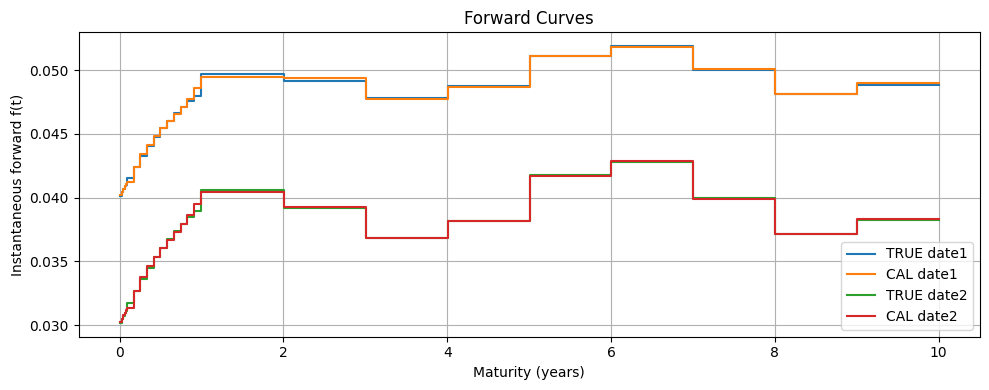

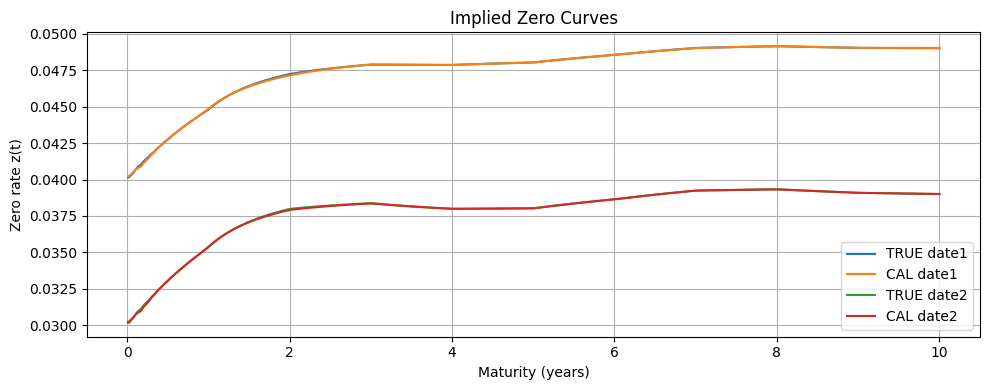

In [10]:
# Build a frozen Market for Date 1 and price something
curve_date1 = FwdCurve(
    curve_id=curve_id,
    knot_times=jnp.array(knot_times),
    forward_params_per_interval=jnp.array(params_1.forward_params_per_interval),
)
market_date1 = Market(curves={curve_id: curve_date1})

pricer = SwapPricer()

# Pricing example: pick maturity closest to 5Y (+ spot shift already in the grid)
target = 5.0 + yearfrac_from_days(2)
picked_maturity = float(maturities[np.argmin(np.abs(maturities - target))])

example_swap = SwapSpec(
    instrument_id=InstrumentId("EXAMPLE_SWAP"),
    maturity=picked_maturity,
    discount_curve=curve_id,
)

par_rate = pricer.par_rate(market_date1, example_swap, ctx)
pv_at_par = pricer.pv(market_date1, example_swap, fixed_rate=par_rate, ctx=ctx)
pv_bumped = pricer.pv(market_date1, example_swap, fixed_rate=par_rate + 10e-4, ctx=ctx)  # +10bp

print("\n--- Pricing example (Date 1 calibrated market) ---")
print("Example maturity (years):", picked_maturity)
print("Par rate:", par_rate)
print("PV at par (should be ~0):", pv_at_par)
print("PV at par+10bp:", pv_bumped)

# Plot (true vs calibrated)
plot_forward_and_zero(
    knot_times,
    curves_forward=[
        true_forward_1,
        params_1.forward_params_per_interval,
        true_forward_2,
        params_2.forward_params_per_interval,
    ],
    labels=["TRUE date1", "CAL date1", "TRUE date2", "CAL date2"],
)